# Objective
To make a CNN classifier with best possible metrics on the cifar 10 dataset. In the process we will use and explore different model architectures

In [29]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [30]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from keras.utils import image_dataset_from_directory
from keras.layers import Input, Dense, Conv2D, Flatten, Rescaling
from keras.models import Sequential
from src.utils import plot_metrics, plot_feature_maps
from src.model_class import FullyGeneralizedCNN
import tensorflow as tf
from sklearn.model_selection import train_test_split


### Data loader and Dataset

In [ ]:
# 1. Load your metadata CSV
df = pd.read_csv("../data/raw/trainLabels.csv")
df['label'] = df['label'].astype('category')
class_names = df['label'].cat.categories.tolist() 
df['label'] = df['label'].cat.codes


# 2. Split your DataFrame into Train (80%) and Validation (20%)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# 3. Use tf.data to build a fast, modern pipeline from your CSV
def load_and_preprocess_image(filename, label):
    # 1. Safely convert integer/int64 filenames to string tensors
    filename_str = tf.strings.as_string(filename)
    
    # 2. OPTIONAL: If your CSV lacks extensions, append it here (e.g., '.jpg')
    # If your CSV already includes '.jpg', change this to: filename_str = filename_str
    filename_str = tf.strings.join([filename_str, ".png"]) 
    
    # 3. Join with your base directory path
    img_path = tf.strings.join(["../data/raw/images/", filename_str])
    
    # 4. Read and process the image
    img = tf.io.read_file(img_path)
    img = tf.io.decode_png(img, channels=3) 
    img = tf.image.resize(img, (32, 32))
    return img, label

def create_dataset(dataframe):
    filenames = dataframe['id'].values
    labels = dataframe['label'].values
    
    dataset = tf.data.Dataset.from_tensor_slices((filenames, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)
    return dataset

# 4. Generate your final datasets
train_dataset = create_dataset(train_df)
val_dataset = create_dataset(val_df)

In [32]:
# dropping the 'id' column from the labels dataframe
# labels = pd.read_csv('../data/raw/trainLabels.csv')
# labels.drop('id', axis=1, inplace=True)

In [33]:
# Ordinal encoding the labels to convert them into numerical format and preparing them fit for the dataloader wrapper
# enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=10, max_categories=10, encoded_missing_value=10)
# y_train = enc.fit_transform(labels).astype(int).flatten()


In [34]:
# Creating the training dataset using image_dataset_from_directory
# train_dataset = image_dataset_from_directory("../data/raw/images", labels = y_train.tolist(), label_mode = 'int', color_mode="rgb", batch_size=32, image_size=(32, 32), validation_split=0.2, subset="validation", seed=42)

### Preparing the Baseline Model

In [35]:
def build_baseline_model():
    baseline_model = Sequential()

    baseline_model.add(Input(shape=(32, 32, 3)))
    baseline_model.add(Rescaling(1./255))
    baseline_model.add(Conv2D(32, (3, 3), use_bias=True, activation="relu"))

    # Classifier Head
    baseline_model.add(Flatten())
    baseline_model.add(Dense(64, use_bias=True, activation="relu"))
    baseline_model.add(Dense(10, activation="softmax"))

    baseline_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    baseline_model_history = baseline_model.fit(train_dataset, epochs=10, verbose = 0)

    return baseline_model, baseline_model_history

In [ ]:
baseline_model, baseline_model_history = build_baseline_model()

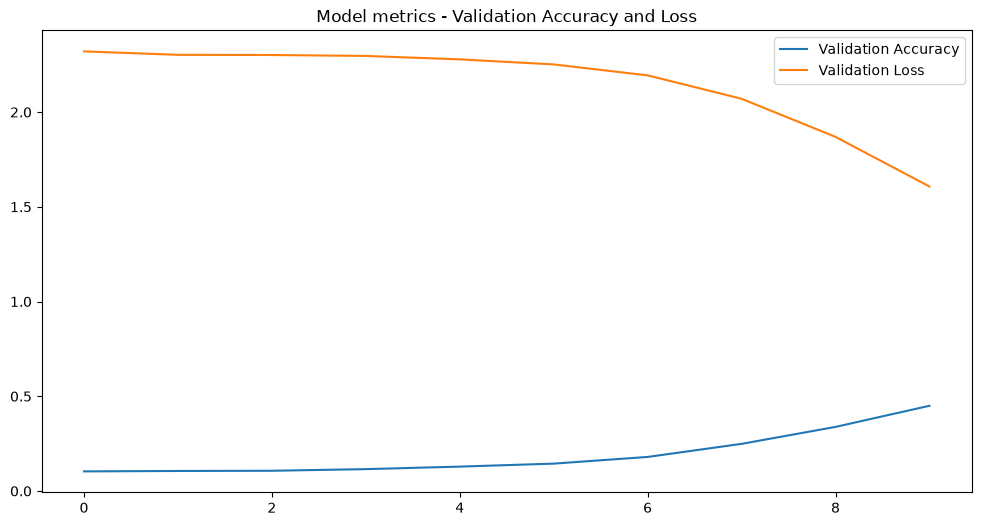

Baseline model accuracy: 44.98%


In [8]:
plot_metrics(baseline_model_history)
baseline_model_accuracy = baseline_model_history.history['accuracy'][-1] * 100
print(f"Baseline model accuracy: {baseline_model_accuracy:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


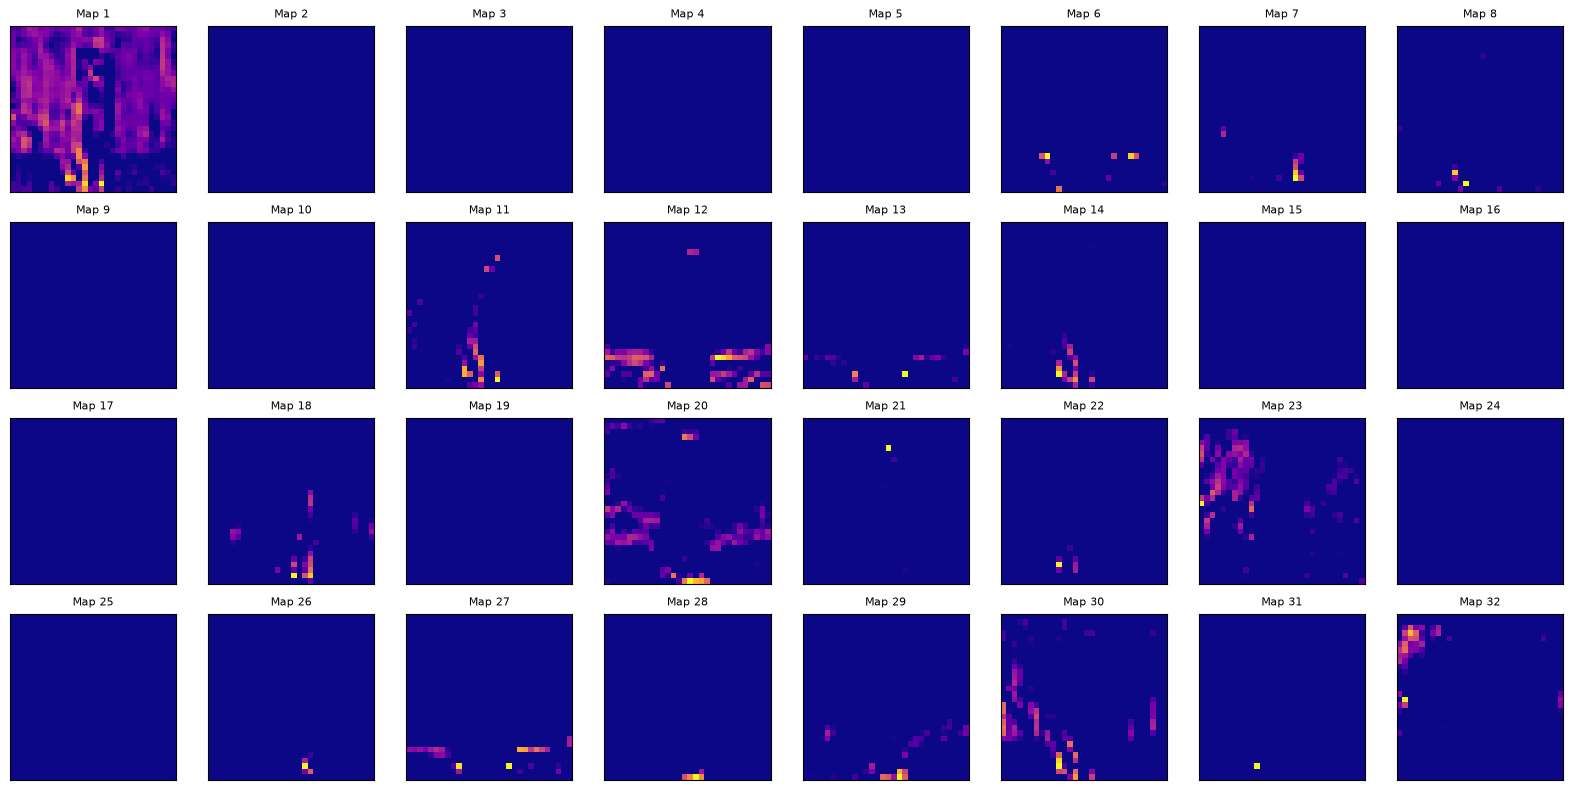

In [9]:
plot_feature_maps(baseline_model, 1, '../data/raw/sample.jpg')

### Observation
Sometimes it gives high accuracies of around 70%+ whereas sometimes performs below 15%. This happens because internal covariate shift and dying relu problems. Sometimes they happen sometimes they not

## Adding BatchNorm and and deepening the CNN model

In [10]:
def handle_case(use_batch_norm, use_max_pooling, strides, padding):
    custom_cnn_model = FullyGeneralizedCNN(use_batch_norm=use_batch_norm, use_max_pooling=use_max_pooling, strides=strides, padding=padding)
    custom_cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    custom_cnn_history = custom_cnn_model.fit(train_dataset, epochs=10, verbose=0)
    cnn_model_accuracy = custom_cnn_history.history['accuracy'][-1] * 100
    print(f"Custom CNN model accuracy: {cnn_model_accuracy:.2f}%")
    plot_metrics(custom_cnn_history)
    return custom_cnn_model, custom_cnn_history

### 1. Deeper Model without batchNorm and Max Pooling Layer with padding same

Custom CNN model accuracy: 10.32%


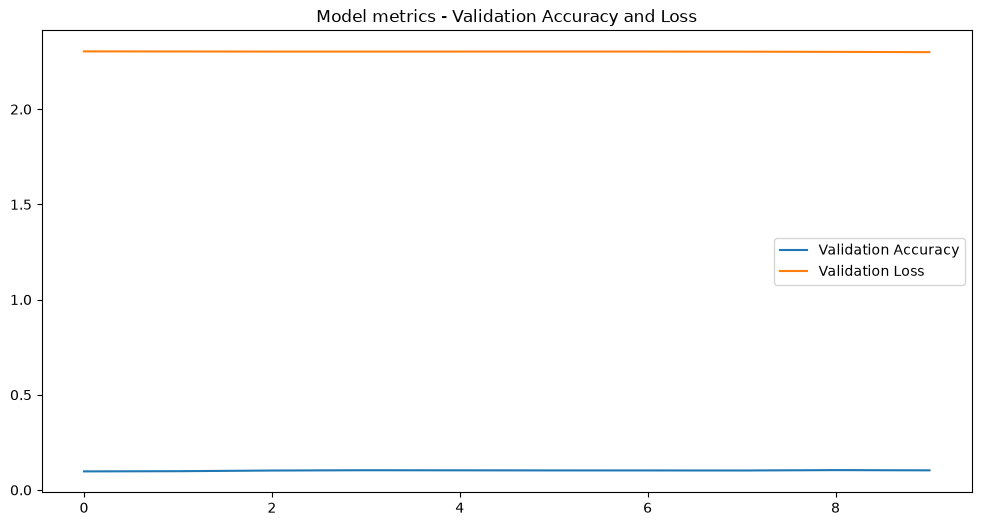

(<FullyGeneralizedCNN name=fully_generalized_cnn, built=True>,
 <keras.src.callbacks.history.History at 0x125a512b0>)

In [11]:
handle_case(use_batch_norm=False, use_max_pooling=True, strides=(1, 1), padding="same")

### 2. Deeper Model with batchNorm and Max Pooling Layer with padding same
As without batchNorm dying relu etc problems can occur and that too when the model is big so we will use for every model now

Custom CNN model accuracy: 66.95%


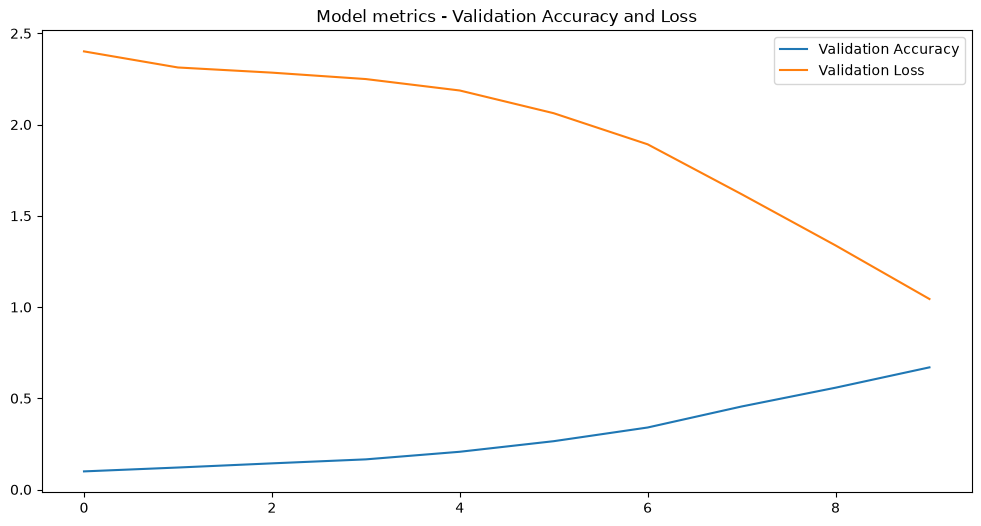

(<FullyGeneralizedCNN name=fully_generalized_cnn_1, built=True>,
 <keras.src.callbacks.history.History at 0x1260ae930>)

In [12]:
handle_case(use_batch_norm=True, use_max_pooling=True, strides=(1, 1), padding="same")

### 3. Deeper Model with batchNorm and without Max Pooling Layer with padding same
We wont compress the parametrs by pooling but by increasing the strides of conv layer

Custom CNN model accuracy: 78.29%


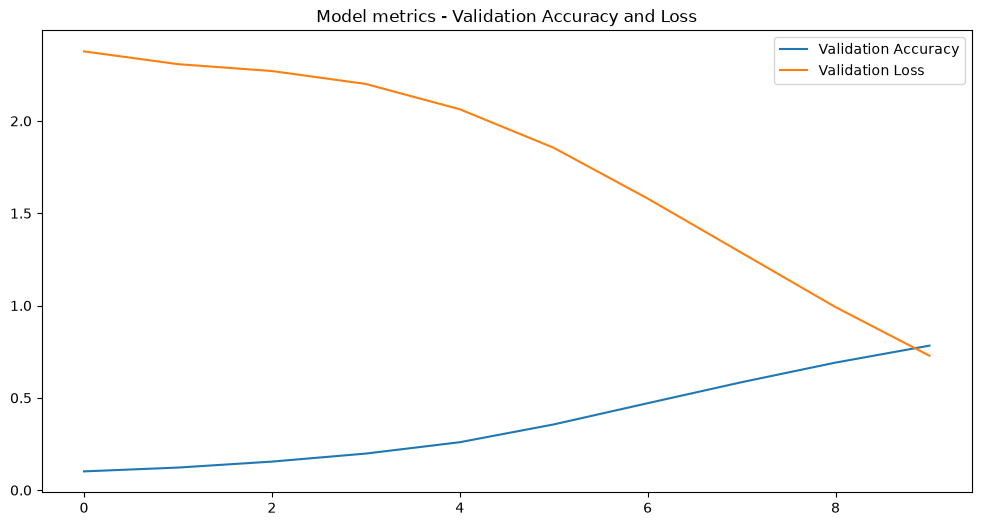

(<FullyGeneralizedCNN name=fully_generalized_cnn_2, built=True>,
 <keras.src.callbacks.history.History at 0x1261c4590>)

In [13]:
handle_case(use_batch_norm=True, use_max_pooling=False, strides=(2, 2), padding="same")

Custom CNN model accuracy: 81.20%


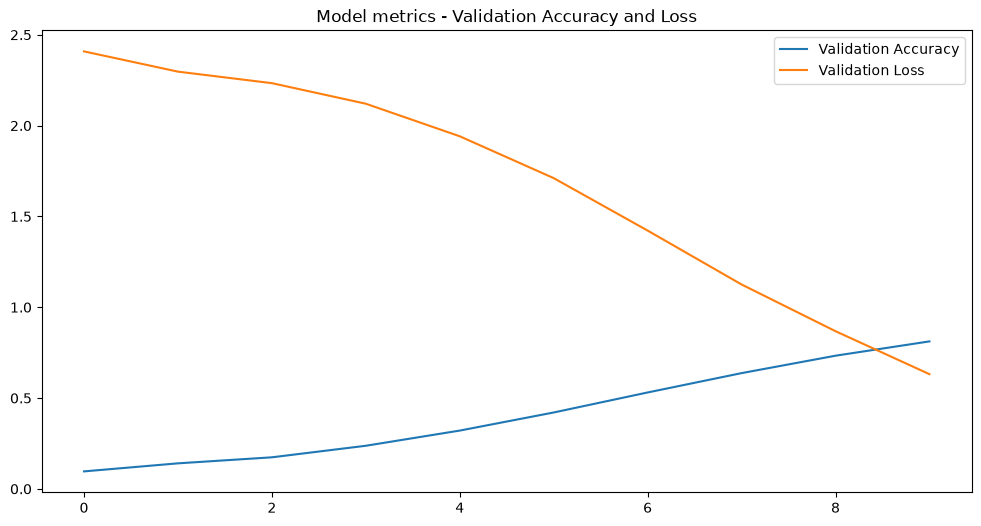

(<FullyGeneralizedCNN name=fully_generalized_cnn_3, built=True>,
 <keras.src.callbacks.history.History at 0x1260aca40>)

In [ ]:
handle_case(use_batch_norm=True, use_max_pooling=False, strides=(2, 2), padding="valid")